# Tutorial 4: Introduction to Inferential Statistics in Python
------------------------------------------------------------------------------------------------------------------

## Overview
The purpose of performing **inferential statistics** in Python for bioinformatics is to make data-driven conclusions about biological phenomena, often from limited samples, while accounting for uncertainty. 
 discoveries. Some parts of this tutorial will remind you of statistical analysis you should already know while introducing you to how the analysis can be performed with Python (Pandas, Numpy, and scikit-learn)
 
## Learning objectives
After this tutorial, you should be able to:
- Carry out essential statistical methods, including ttests, ANOVAS, and correlations
- Perform linear regression & query the OLS data
- Compare model fits
  
## Prerequisites
- You should be comfortable with Pandas and NumPy before using this tutorial
- A background in biostatistics is necessary, as this tutorial generally will assume you know why you would want to do particular statistical analysis
  
## Getting started
Please run the next code box to import the needed libraries, including
- Numpy, Pandas, Matplotlib
- Seaborn, statsmodels
- Scikit-learn

In [1]:
%pip install matplotlib
%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
print("All required packages have been installed")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All required packages have been installed


# Why do inferential statisics in python?

Bioinformatics typically involves large, complex datasets like gene expression levels, mutation rates, or protein interactions, and inferential statistics helps uncover patterns, relationships, and insights within this data. For example:

1. **Hypothesis Testing**: Determine whether observed differences (e.g., gene expression under two conditions) are statistically significant.
   - Example: Is a gene upregulated in diseased tissue compared to healthy tissue?
   
2. **Estimating Parameters**: Infer population characteristics, such as mutation frequencies or species diversity, from sample data.
   - Example: Estimating the prevalence of a mutation in a population from sequencing data.

3. **Correlations and Relationships**: Assess relationships between variables, such as gene expression levels and phenotypes, or identify co-expressed genes.
   - Example: Is the expression of a gene correlated with disease severity?

4. **Clustering and Classification**: Use statistical methods to group similar biological entities (e.g., clustering genes based on expression patterns) or classify data (e.g., distinguishing tumor subtypes).

Python, with libraries like **statsmodels** and **scikit-learn**, provides robust tools for inferential statistics, making it ideal for analyzing bioinformatics datasets. These tools help researchers efficiently handle large datasets, automate workflows, and visualize results, enabling reproducible and insightful biological discoveries.

## Our Working Datasets 

Stats models comes with several datasets that can be loaded as a pandas Dataframe
Load a few different pandas datasets.

In [2]:
import pandas as pd
import os
## get datasets
prot_exp=pd.read_csv("." +os.sep + "Datasets" + os.sep + "sim_prot_exp.csv")
mtcars = pd.read_csv("." + os.sep + "Datasets" + os.sep + "mtcars.csv")
mtcars["am"] = mtcars["am"].replace({0: "Automatic", 1: "Manual"})
mtcars["Transmission"]=mtcars["am"]
del mtcars["am"]
mtcars.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,gear,carb,Transmission
0,21.0,6,160.0,110,3.90,2.620,16.46,0,4,4,Manual
1,21.0,6,160.0,110,3.90,2.875,17.02,0,4,4,Manual
2,22.8,4,108.0,93,3.85,2.320,18.61,1,4,1,Manual
3,21.4,6,258.0,110,3.08,3.215,19.44,1,3,1,Automatic
4,18.7,8,360.0,175,3.15,3.440,17.02,0,3,2,Automatic


### Describe the data
We might be interested in comparing MPG’s across different automatic versus manual transmissions to test the hypothesis that **Manual transmission vehicles get better gas mileage than automatic.**
We can first investigate the data on the 32 cars in the mtcars dataset. We'll use the convenient groupby object from Pandas

                   mean       std
Transmission                     
Automatic     17.147368  3.833966
Manual        24.392308  6.166504


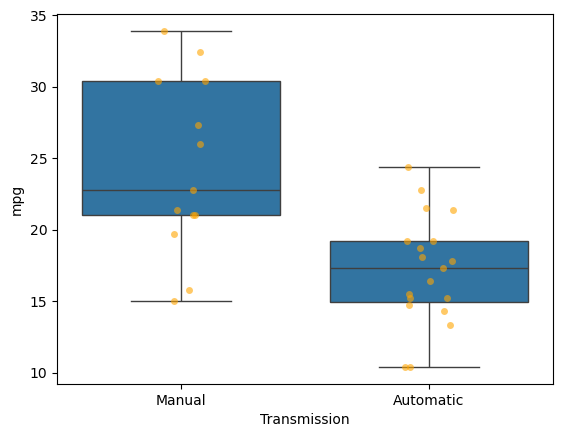

In [59]:
## Comparing Two Distributions
mtcars_group=mtcars.groupby("Transmission")
result=mtcars_group["mpg"].agg(["mean","std"])
print(result)
sns.boxplot(x="Transmission", y="mpg", data=mtcars);
sns.stripplot(x="Transmission", y="mpg", data=mtcars, color="orange", alpha=0.6, jitter=True);

The means and the medians are numerically different for the two transmission types, but the data all seems to overlap and there is not as much data for manual transmissions. This requires statistical tests.

## Essential Statistical Methods for Data Analysis

### Comparing Normal Distributions

If we ask the question, "Do the miles per gallon (mpgs) differ by transmission (trans)?", what do we mean statistically by this? 

To start answering this question, how would you describe the distribution of mpgs, independent of transmission type? (in code below

In [49]:
## Sufficient Statistics for the normal distribution
cars_mpg_mean=mtcars.mpg.mean()
cars_mpg_var= mtcars.mpg.var()
print("The overall mpg mean is " + str(cars_mpg_mean.round(2)) + " with variance " + str(round(cars_mpg_var,2)))

The overall mpg mean is 20.09 +/-36.32


Perhaps you have heard of the "central limit theorem (CLT)?" This theorem says that no matter the underlying distribution of some values, if we take a sample and then calculate the sample average, the distribution of those sample averages will be **normal.**
<br>So, how do we estimate the underlying population mean?
We start by calculating the sample average and the sample variance

### Comparing Two Distributions
When we compare two distributions, we are really comparing the sample average distributions..
Then, what does it mean to conclude two distributions are different?
That means we believe their underlying population means are different!
“Sure they are different, but are they statistically significantly different? “

We can visually compare the two different distributions of data.
We might start to ask ourselves if they **look that different** and if we have **normally distributed data**. 
Remember, the bigger the difference OR the more observations I have, the more certain I am of the result…

First, a histogram of the data to look for the distribution

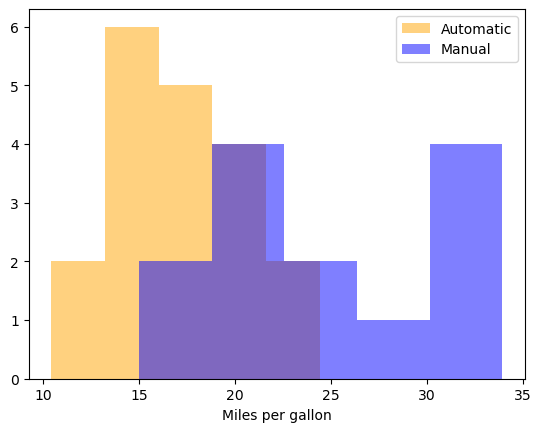

In [117]:
## Compare MPGs across groups
#mtcars_group.mpg.hist();
colors = {"Manual": "blue", "Automatic": "orange"}  # Define colors for groups
for name, group in mtcars_group:
    plt.hist(group["mpg"], bins=5, alpha=0.5, label=name, color=colors[name])
plt.xlabel("Miles per gallon")
plt.legend()

The two groups have relatively small numbers, so it is hard to see a bell-shaped curve, especially for the manual transmission cars.

It does APPEAR that the means are different, but how can we feel confident?

### P-Values

Imagine you are flipping a coin. Will the next flip be heads or tails?
For one flip, it is easy: there is a 50% probability for each. But what if the
next three flips were all heads? The next 10? The next 50?
Would you still think there was an equal possibility for a head or tail 
on the next flip or would you conclude (infer) the coin was not actually fair?

Here's where the p-value comes in. The p-value gives us a threshold by which we make a
determination whether a given hypothesis is valid or not.

You could define a p-value this way:

“Given some hypothesis, what is the probability of getting this result (or one more extreme) assuming the null (or opposite) hypothesis is true?”

In other words, suppose you believe the coin in the last example is "not fair". What is the probability, given the null
hypothesis (the coin is "fair") that you would get 10 heads in a row?
You can calculate the p-value as 1/2^10 or 1/1024 or less than .1%. This means there is less than a .1% chance a fair coin will give you ten heads in a row.

What does that mean in this case. If you set your threshold of 5% and your p-value is less (in this case it is) than the null hypothesis is "false", meaning you can infer the coin that the opposite is true or that the coin is NOT fair. This is how inferential statistics works.
Now let's see how that applies to comparing two distributions.
Hypothesis: The distributions are different.
Null hypothesis: The distribtions are the same.

<mark>We can  use statistical tests such as the t-test or the Welch's t-test to generate
a p-value for comparison.</mark>

We'll import a tool for ttest from the scipy.stats library

Our standard will be to NOT REJECT the hypothesis if p<0.01


In [130]:
from scipy.stats import ttest_ind
# Extract groups
autoT = mtcars[mtcars["Transmission"] == "Automatic"]["mpg"]
manT = mtcars[mtcars["Transmission"] == "Manual"]["mpg"]

# Perform independent two-sample t-test
t_stat, p_value = ttest_ind(autoT, manT)

print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: -4.106126983100689, p-value: 0.0002850207439350686


<div class="alert alert-block alert-success"> <b>Success:</b>The p-value was less than 0.01, so we conclude that the gas mileage is higher for manual transmission.</a>. </div>

### Test your knowledge
Now it's your turn to repeat this analysis for different data. 
We used the protein expression dataframe in the Visualizing Data module (prot_exp) which we already loaded 

1. Groupby "group" (control & treated)
2. Create a histogram of the data
3. Measure the mean & variance
4. Create a boxplox of the two groups (Treated, Control)
5. Perform a ttest & determine the probability that the two samples come from different distributions (the p-value) to answer the quiz question.

*The solution is at the end of this tutorial.*

In [ ]:
#TTest task on prot_exp


In [73]:
from jupyterquiz import display_quiz
import os
ttest_prot= "." +os.sep + "PythonQuizQuestions" + os.sep +"prot_ttest.json"
display_quiz(ttest_prot)

<IPython.core.display.Javascript object>

### ANOVA
What if there are more than two distributions to test? For that we can use a more
sophisticated test such as ANOVA (assuming normal distribution) or the Kruskal-Wallis 
test (for medians).

We now are asking the questions:
1. are these population means unequal?
2. Is at least one of the group means not equal to the others?

The formal statistical test for this comparison is an **ANOVA**

The mtcars dataframe has representative cars with different numbers of cylinders (cyl). We can ask whether the mpg differs between those groups with an ANOVA.

There are many Python tools for performing ANOVA. We'll show 2 different approaches. 

First, we'll manually break the data into groups based on the number of cylinders then show how statsmodel can determine the groups & analyze.


In [120]:
#What categories are there for the number of cylinders in the cars?
mtcars["cyl"].unique()

array([6, 4, 8], dtype=int64)

We know what our categories are, so we can break the data into groups based on the number of cylinders & use scipy's library for calculating the one-way F-statistic (technically the value used to perform the ANOVA)

In [115]:
# Scipy's approach requires that you know the identities of your groups
from scipy.stats import f_oneway

# Split the data into groups
group_4 = mtcars[mtcars["cyl"] == 4]["mpg"]
group_6 = mtcars[mtcars["cyl"] == 6]["mpg"]
group_8 = mtcars[mtcars["cyl"] == 8]["mpg"]

# Perform ANOVA
f_stat, p_value = f_oneway(group_4, group_6, group_8)

print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}") #.2f and .4f tell how many decimals to provide, 2 or 4

F-statistic: 39.70, p-value: 0.0000


Rather than having to create our own groups to compare, since that is tedious, we can let statsmodel do the work. 

Run the code below then read the explanation after.

In [75]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Create an OLS model
model = ols("mpg  ~ C(cyl)", data=mtcars).fit()


              sum_sq    df          F        PR(>F)
C(cyl)    824.784590   2.0  39.697515  4.978919e-09
Residual  301.262597  29.0        NaN           NaN


We ask python to perform an ordinary least squares (OLS) fit of the mtcars data, comparing mpg to the number of cylinders.

By writing C(cyl) we tell the tool that it should treat cyl not as a continuous variable (the default) but as a category.

The C(cyl) indicates that the variable cyl (number of cylinders) is treated as categorical.
Without C(), cyl would be treated as a continuous numerical variable.
By using C(cyl), you're instructing the model to group cyl into categories (e.g., 4 cylinders, 6 cylinders, 8 cylinders).

Now, run the next code

In [134]:
# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

              sum_sq    df          F        PR(>F)
C(cyl)    824.784590   2.0  39.697515  4.978919e-09
Residual  301.262597  29.0        NaN           NaN


The statsmodel tool:
- Performs the ANOVA on the fitted model.
- Type II ANOVA calculates the sum of squares for each variable adjusted for others.
- The output (anova_table) provides the statistical evidence (F-statistic and p-value) to test whether the independent variable(s) significantly affect the dependent variable.

In this case, as with the previous ANOVA using f_oneway, we see that **the mpg IS affected by the number of cylinders (p<0.01)** in this case giving us the value: 5e-9

### Test your knowledge
You are ready to perform an ANOVA on a different dataset (mut_rate.csv) in the Datasets folder

Context: The numbers are mutation rates (e.g., mutations per 100,000 bases) for genomes sequenced from different groups. For example:
- Group_A: Mutation rates in normal tissue samples.
- Group_B: Mutation rates in tumor tissue.
- Group_C: Mutation rates in metastatic tissue.

You can use ANOVA to test the following hypotheses:
- Null Hypothesis: The mean mutation rates are equal across all groups (e.g., normal tissue, tumor tissue, and metastatic tissue).
- Alternative Hypothesis At least one group's mean mutation rate is significantly different from the others.

A solution is at the end of this tutorial.

In [ ]:
#ANOVA for mut_rate.csv
#load into a Pandas dataframe
import os
#examine the first few lines to be sure of column names

In [36]:
from jupyterquiz import display_quiz
mut_anova_qz="." +os.sep + "PythonQuizQuestions" + os.sep + "mut_anova.json"
display_quiz(mut_anova_qz)

<IPython.core.display.Javascript object>

## Comparing Continuous distributions

We just compared continuous distributions with *categorical* distributions

What about a continuous distribution with a *continuous* distribution?

We typically summarize continuous-by-continuous relationships as a **correlation.**

Simply put, do these variables move together? Is there a relationship between them? 

Seaborn libraries can help us to see these relationships in mtcars.

Run the next code box to show the full data pattern for the relationship between engine displacement (disp) or horsepower (hp), with the two histograms on the x & y axis. 

The scatterplot shows the x-y data and the correlation line (solid) with the confidence interval of the line in light blue. 

(Think about how long it would take to get Excel to make even part of these plots!)

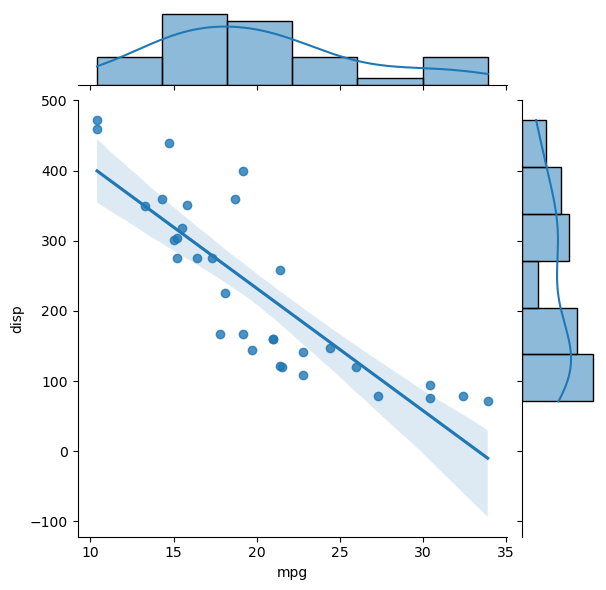

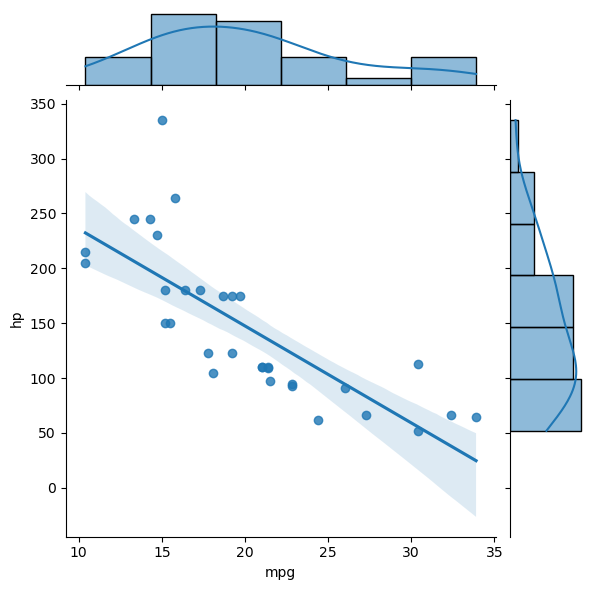

In [138]:
## Correlation
## seaborn image 
sns.jointplot(x="mpg", y="disp", data=mtcars, kind="reg")
sns.jointplot(x="mpg", y="hp", data=mtcars, kind="reg");

We observe that the fit to the displacement~mpg may be slightly better than that of horsepower, but this should be evaluated quantitatively.

### Calculate Correlation

We can calculate correlation as shown below. The default method is linear correlation (Pearson).

In [62]:
## Examine the linear correlation between mpg and other values
mtcars.loc[:,["mpg","disp","hp"]].corr()

## Calculate the covariance
#mtcars.loc[:,["mpg","disp","hp"]].cov()


,mpg,disp,hp
mpg,1.000000,-0.847551,-0.776168
disp,-0.847551,1.000000,0.790949
hp,-0.776168,0.790949,1.000000


#### Meeting assumptions?
Python is willing to perform statistical tests on whatever data you feed it. If you ask commercial stats software (e.g., SigmaPlot) to do this, it first runs normality test on the data. This is because it is illegitimate to perform Pearson correlations which assumes normal distributions. If normality is violated, one can use Spearman correlation, which does not assume normality.

Scipy provides the tools for the Shapiro-Wilk test of normality. It's so easy to run that we have no excuse for ignoring this possible violation. 

The next box shows the Shapiro-Wilk test on these 3 parameters in mtcars.

In [60]:
from scipy.stats import shapiro

# Check normality of 'hp'
stat_hp, p_hp = shapiro(mtcars['hp'])
print(f"Shapiro-Wilk test for 'hp': p-value = {p_hp:.4f}")

# Check normality of 'disp'
stat_disp, p_disp = shapiro(mtcars['disp'])
print(f"Shapiro-Wilk test for 'disp': p-value = {p_disp:.4f}")

# Check normality of 'mpg'
stat_mpg, p_mpg = shapiro(mtcars['mpg'])
print(f"Shapiro-Wilk test for 'mpg': p-value = {p_mpg:.4f}")

Shapiro-Wilk test for 'hp': p-value = 0.0488
Shapiro-Wilk test for 'disp': p-value = 0.0208
Shapiro-Wilk test for 'mpg': p-value = 0.1229


The mpg IS normal (accept null hypothesis since p>0.05) but, not surprisingly, the displacement and horsepower are NOT normal (after all, they are selected by manufacturers.)

We should therefore not do the default Pearson correlation but rather the Spearman version. This is a simple switch to tell the correlation function which method to use.

The correlation coefficients are about 0.1 units different from Pearson.

In [64]:
#Perform a Spearman correlation on the mtcars data
mtcars.loc[:,["mpg","disp","hp"]].corr(method="spearman")

,mpg,disp,hp
mpg,1.000000,-0.908882,-0.894665
disp,-0.908882,1.000000,0.851043
hp,-0.894665,0.851043,1.000000


Now, it's your turn. Use the provided dataset with three variables: Gene_expression, Protein_Abundance & Disease_Severity. Assess the normality then, using either Pearson or Spearman, determine the correlations. 

Then, check your answers with the quiz.

In [23]:
import pandas as pd
from scipy.stats import shapiro
import os
disease= pd.read_csv("."+ os.sep+ "Datasets" +os.sep + "bioinform_disease.csv")

# Check normality

# Calculate correlations between the 3 variables


,Gene_Expression,Protein_Abundance,Disease_Severity
Gene_Expression,1.000000,0.855683,-0.877023
Protein_Abundance,0.855683,1.000000,-0.742276
Disease_Severity,-0.877023,-0.742276,1.000000


In [27]:
from jupyterquiz import display_quiz
dis_cor= "."+ os.sep + "PythonQuizQuestions" + os.sep + "disease_corr_qz.json"

display_quiz(dis_cor)

<IPython.core.display.Javascript object>

### Linear Regression

We will focus, for now, on regular linear regression for multivariate statistics, but all lessons learned apply to other methods. 

What are the assumptions of linear regression?
- Independence
- Normality
- Linearity
- Homoscedasticity

Y ~ B0 + B1 * X1 + B2*X2

Linear Regression is the heart of modern frequentist statistics
Explore relationships between predictors and an outcome
There are different types of regression (see below).
Use regression to answer certain questions, but also understand your inputs.
  What type of data?
  What size of data?
  What are your intended outputs?


### Regression Types in this tutorial
While there are many possible relationships we might want to evaluate between continuous or categorical variables, this tutorial will show you the basics of: 

- OLS Regression, or simple linear regression, in forms we've already seen (partially)

- Multiple Linear Regression
    As a predictive analysis, multiple linear regression is used to explain the relationship between one 
    continuous dependent variable and two or more independent variables.

= Polynomial regression


### The General Regression Strategy

Regression analysis requires a series of steps:
1. Collect appropriate data
2. Identify Outcomes / predictors
3. Investigate "shape" of data
4. Consider appropriate functional form
5. Apply prior knowledge
6. Select "best" model and variables
7. Check model for validity (residuals, etc)
8. Apply model
9. Predict new results

Python tools can be used for the last 4 which we will demonstrate below. Again, the assumption is that the analytical technique is being demonstrated rather than teaching the foundational statistics.

### Ordinary Least Squares (OLS) Regression

Ordinary Least Squares is a method used in regression analysis to estimate the coefficients of a <u>linear</u> model by minimizing the sum of squared residuals (the squared differences between the observed and predicted values). This method ensures that the regression line (or hyperplane, in the case of multiple regression) best fits the data.

It is easy to learn conceptually and you are probably familiar with this process. 

In bioinformatics, we use OLS for many things, including:
- **Gene Expression Analysis:** To identify relationships between gene expression levels and experimental conditions or phenotypes.
- **Genome-Wide Association Studies (GWAS):** To model associations between genetic variants (e.g., SNPs) and traits of interest.
- **Protein-Protein Interaction Modeling:** To predict interactions based on quantitative features like binding affinities or structural properties.
- **Medication Dosage vs. Treatment Effect:** To determine the relationship between drug dose and improvement in patient symptoms.

For OLS regression, we have to make some assumptions (this is key): Normality, Independence, Linearity, Homoscedasticity  *but we won't discuss these here- rather, just how to make the calculations*

Formula: y = xb + e or y = b0 + b1x + e
- x – some input
- b – some vector of parameters
- e – some error
- B0 – constant/y-intercept
- B1 - slope

Try to write out the regression equation that is being fit below. 
We are regressing am on mpg. You are looking for b0, b1, assume e = 0.

In [43]:
## Linear Regression with One predictor
## Fit regression model
mtcars2=pd.read_csv("."+ os.sep + "Datasets" + os.sep + "mtcars.csv")
mtcars2["constant"] = 1
X = mtcars2.loc[:,["constant","am"]]
Y = mtcars2.mpg
mod1res = sm.OLS(Y, X).fit()

### Model Summary Results

Use Python to inspect the 'OLS results object' with summary, with two different format functions (summary1 & summary2)

In [91]:
## Inspect the results
print(mod1res.summary())
print("\nVersion summary2 below")
print(mod1res.summary2()) ## different format

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     16.86
Date:                Tue, 07 Jan 2025   Prob (F-statistic):           0.000285
Time:                        23:59:21   Log-Likelihood:                -95.242
No. Observations:                  32   AIC:                             194.5
Df Residuals:                      30   BIC:                             197.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
constant      17.1474      1.125     15.247      0.0


That output can be overwhelming. 

Let's examine the model for some *specific* traits by calling out particular values.
    Use dir(mod1res) to see all the methods.

In [49]:
## Get AIC for model
print("AIC: " + str(mod1res.aic))
## Get r-squared
print("rsq: " + str(mod1res.rsquared))
## r-squared penalized for the number of parameters
print("mod rsq: " + str(mod1res.rsquared_adj))

## Mean squared error...?
1 - mod1res.mse_resid/mod1res.mse_total
print("mse: " + str(mod1res.mse_model))

AIC: 194.48438008188828
rsq: 0.35979894342546515
mod rsq: 0.33845890820631397
mse: 405.15058830971657


We can also pull out the **residuals.**

Residuals in regression analysis are the differences between the observed values and the predicted values produced by the regression model. They represent the part of the data that the model could not explain.

In [ ]:
## View residuals
mod1res.resid
mod1res.resid_pearson
## View Predicted Values
mod1res.predict()

## Get the influence of each value? DBETAS?
mod1res.get_influence()

## View available model attributes
dir(mod1res)

We can request some automatic plots using stats models graphics.

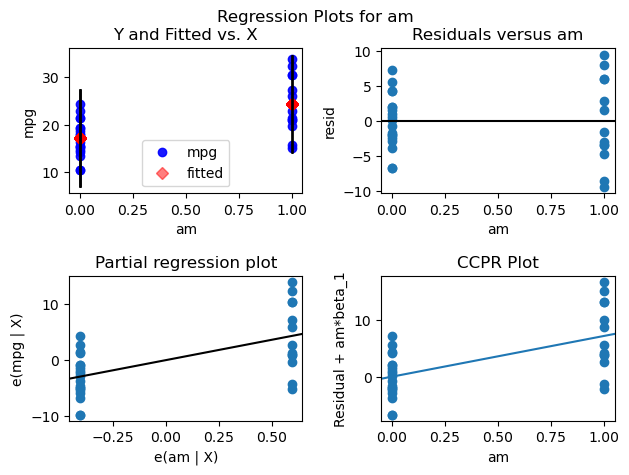

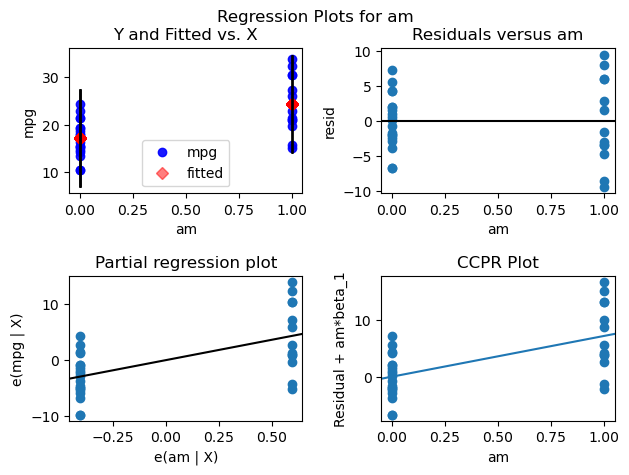

In [93]:
## Goodness of fit
## Find outlier observations
mod1res.outlier_test()

## Goodness of fit plots
sm.graphics.plot_regress_exog(mod1res, "am")

Regression with Categorical
We can fit a regression with a categorical predictor as well. 
(Note the add_constant function)

In [95]:
## Linear Regression with Categorical predictors
## mpg and cylinder
## Fit regression model
mtcars["constant"] = 1
X = mtcars.loc[:,["constant","cyl"]]
Y = mtcars.mpg
mod2res = sm.OLS(Y, X).fit()
print(mod2res.summary())
## Alternatively:
X = sm.add_constant(mtcars.cyl)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     79.56
Date:                Wed, 08 Jan 2025   Prob (F-statistic):           6.11e-10
Time:                        00:01:22   Log-Likelihood:                -81.653
No. Observations:                  32   AIC:                             167.3
Df Residuals:                      30   BIC:                             170.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
constant      37.8846      2.074     18.268      0.0

## Dummy Coding Variables
OLS deals in continuous interpretations. What about categorical variables?

You can fix this by adding a dummy variable. ("One hot coding" as we learned in the [Numpy tutorial](./Submodule_2_Tutorial1_NumPy.ipynb) would also work)

In [ ]:
## We need to dummy code the categorical variable
mtcars['cyl_6'] = 0
mtcars.loc[mtcars.cyl == 6,'cyl_6'] = 1
mtcars['cyl_8'] = 0
mtcars.loc[mtcars.cyl == 8,'cyl_8'] = 1
## Rerun the model with more parameters
X = mtcars.loc[:,["constant","cyl_6","cyl_8"]]
Y = mtcars.mpg
mod3res = sm.OLS(Y, X).fit()
print(mod3res.summary())

In [51]:
## Is there an easier way to set up these matrices?!?
## We can use the formula interface, patsy package
## Formula interface included with statsmodels
## Fit same model
mod4res = smf.ols('mpg ~ C(cyl)', data=mtcars).fit()
mod4res.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     39.70
Date:                Tue, 07 Jan 2025   Prob (F-statistic):           4.98e-09
Time:                        22:01:26   Log-Likelihood:                -81.282
No. Observations:                  32   AIC:                             168.6
Df Residuals:                      29   BIC:                             173.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      26.6636      0.972     27.437      0.000      24.676      28.651
C(cyl)[T.6]    -6.9208      1.558     -4.441      0.000     -10.108      -3.734
C(cyl)[T.8]   -11.5636      1.299     -8.905      0.000     -14.220      -8.908
==============================================================================
Omnibus:                        0.252   Durbin-Watson:                   1.694
Prob(Omnibus):                  0.882   Jarque-Bera (JB):                0.305
Skew:                           0.187   Prob(JB):                        0.859
Kurtosis:                       2.702   Cond. No.                         3.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Multiple Linear Regression
    We can add multiple parameters. 

In [59]:
## Linear regression with multiple predictors

mod5res = smf.ols('mpg ~ C(cyl) + disp', data=mtcars).fit()
mod5res.summary() 

mod6res = smf.ols('mpg ~ C(cyl) + disp + am', data=mtcars2).fit()  #we changed am in mtcars so use mtcars2
mod6res.summary() 

## Does AM add anything?
sm.stats.anova_lm(mod6res, typ=2)


,sum_sq,df,F,PR(>F)
C(cyl),69.821500,2.0,4.090041,0.028080
disp,34.035802,1.0,3.987534,0.056010
am,13.159918,1.0,1.541777,0.225032
Residual,230.459875,27.0,NaN,NaN


# Chosing the best model

We can compare model fits with **AIC** 
- a likelihood-based statistic penalized for the number of parameters

You see that the result of the model fits is that one model is worst, but the other 2 are essentially equally good at fitting the data. 

In [61]:
## comparing model fits - AIC
print("model-6 AIC: ", mod6res.aic)
print("model-5 AIC: ", mod5res.aic)
print("model-4 AIC: ", mod4res.aic)

model-6 AIC:  163.9909739076229
model-5 AIC:  163.76799839108128
model-4 AIC:  168.56395086861536


## Sum of Squared Errors

We can also use R-squared, which can be interpreted as the proportion of variance explained by the model. 
If r-squared goes up, is the model better?
Not necessarily! We need to adjust it (r2)

In [63]:
## Compare Model Fits - r-squared
print("mod6res.rsquared: ", mod6res.rsquared)
print("mod5res.rsquared: ", mod5res.rsquared)
print("mod4res.rsquared: ", mod4res.rsquared)

## Compare Model Fits - r-squared adjusted
print("mod6res.rsquared_adj: ", mod6res.rsquared_adj)
print("mod5res.rsquared_adj: ", mod5res.rsquared_adj)
print("mod4res.rsquared_adj: ", mod4res.rsquared_adj)

mod6res.rsquared:  0.7953372842845954
mod5res.rsquared:  0.7836504579242477
mod4res.rsquared:  0.7324600596255232
mod6res.rsquared_adj:  0.7650168819563873
mod5res.rsquared_adj:  0.7604701498447028
mod4res.rsquared_adj:  0.7140090292548696


## Likelihood Ratio Test

We can use a LRT for models that are “nested”
Meaning one model can be recovered from the other by deleting parameters…
If they are not nested, we must use AIC

In [65]:
## Compare Model fits - likelihood
print("model-6 LLF: ", mod6res.llf)
print("model-5 LLF: ", mod5res.llf)

## Likelihood ratio test
sm.stats.anova_lm(mod5res,mod6res)

model-6 LLF:  -76.99548695381145
model-5 LLF:  -77.88399919554064


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,28.0,243.619793,0.0,NaN,NaN,NaN
1,27.0,230.459875,1.0,13.159918,1.541777,0.225032


Regression Diagnostics

#### Regression Diagnostics
The Seaborn package allows us to visualize lowess curves and reveals potential non-linear relationships.

<Axes: xlabel='mpg', ylabel='disp'>

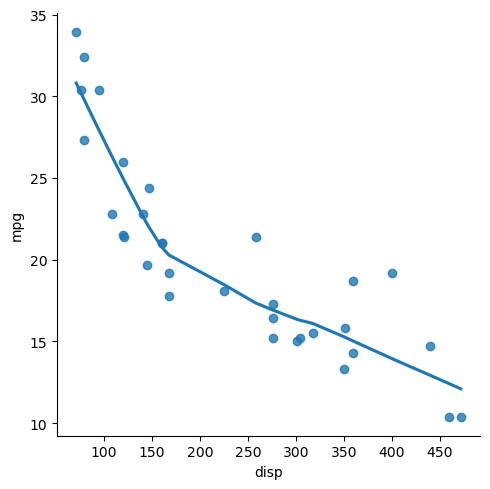

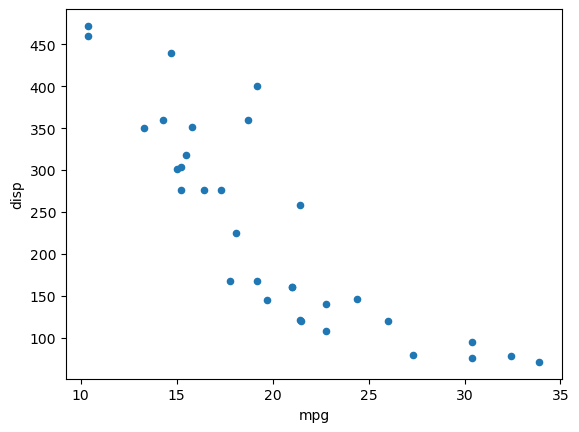

In [67]:
## Seaborn regression diagnostics: non-linear relationships
sns.lmplot(x="disp", y="mpg", data=mtcars, lowess=True)
mtcars.plot.scatter(x='mpg',y='disp')

The statsmodels graphics package has several plot methods that will assist with poor model fit identification. 
Review these on your screen.

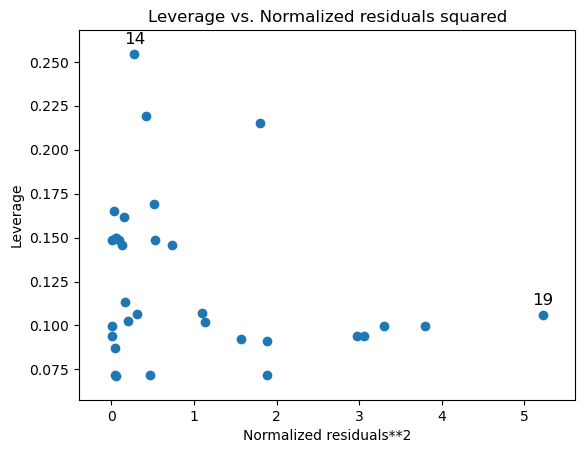

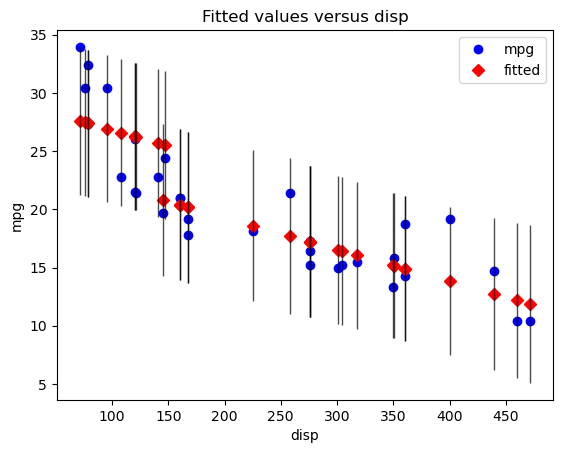

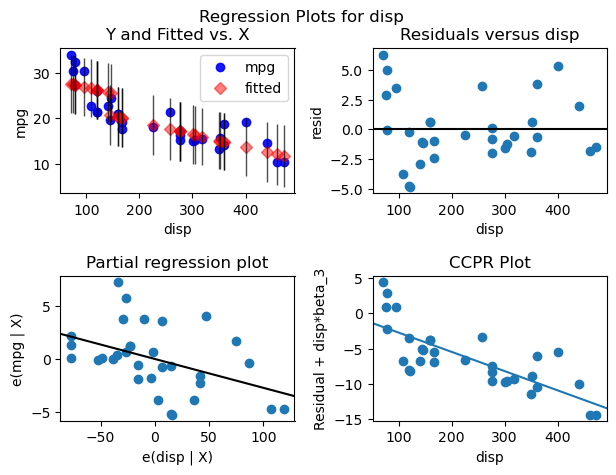

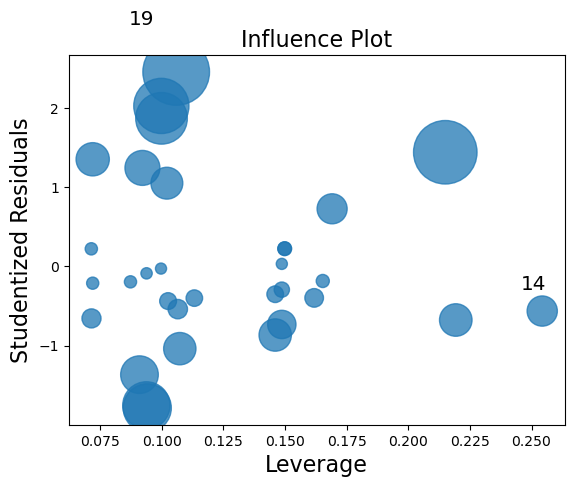

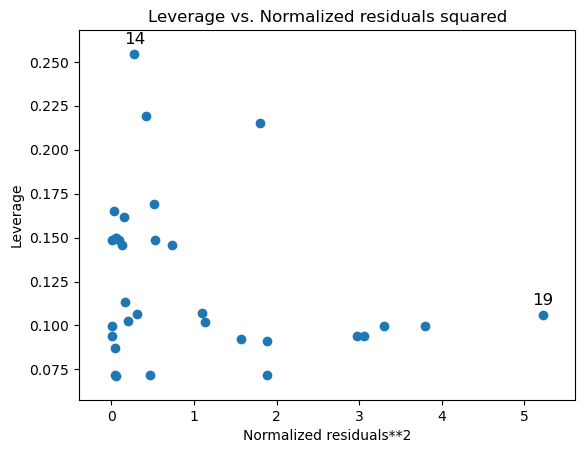

In [70]:
## Examine the goodness of fit plots 
sm.graphics.plot_fit(mod5res,exog_idx=3)
sm.graphics.plot_regress_exog(mod5res,exog_idx=3)
sm.graphics.influence_plot(mod5res)
sm.graphics.plot_leverage_resid2(mod5res)

### Scoring New Data

We are often interested in making predictions using a model, or “scoring” new data. 
We can easily do this with stats models
We must first create a new dataset to score. 

In [73]:
## Scoring Data
## create dataframe
mtcars.cyl.unique()
mtcars.disp.describe()
new_dat = pd.DataFrame({'cyl':mtcars.cyl.unique(),
 'disp':(80,100,120)})
## Predict the new values
mod5res.predict(new_dat)

0    22.564230
1    26.803903
2    21.465645
dtype: float64

### Polynomial Regression

Displacement appeared to have a non-linear relationship with mpg. Perhaps we should fit a quadratic term? 

In [75]:
## Linear regression with polynomials
## add disp squared
mtcars['disp_2'] = mtcars.disp **2
mod7res = smf.ols('mpg ~ disp', data=mtcars).fit()
mod7res.summary() 
mod8res = smf.ols('mpg ~ disp + disp_2', data=mtcars).fit()
mod8res.summary() 
## Did this improve the model fit?
sm.stats.anova_lm(mod8res, typ=2)

,sum_sq,df,F,PR(>F)
disp,216.931788,1.0,26.954610,0.000015
disp_2,83.765519,1.0,10.408188,0.003104
Residual,233.393170,29.0,NaN,NaN


### Using Formulas

We can use formulas when we know or have hypothesized the relationship. 
This has several advantages
When we score data, it will automatically be transformed.
No need to create intermediate columns.

In [77]:
## We can rewrite this with formulas...
smf.ols('mpg ~ disp + disp_2', data=mtcars).fit().summary()
smf.ols('mpg ~ disp + np.square(disp)', data=mtcars).fit().summary()
smf.ols('mpg ~ disp + np.power(disp,2)', data=mtcars).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     55.46
Date:                Tue, 07 Jan 2025   Prob (F-statistic):           1.23e-10
Time:                        22:07:39   Log-Likelihood:                -77.198
No. Observations:                  32   AIC:                             160.4
Df Residuals:                      29   BIC:                             164.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            35.8287      2.209     16.221      0.000      31.311      40.346
disp                 -0.1053      0.020     -5.192      0.000      -0.147      -0.064
np.power(disp, 2)     0.0001   3.89e-05      3.226      0.003     4.6e-05       0.000
==============================================================================
Omnibus:                        1.777   Durbin-Watson:                   1.688
Prob(Omnibus):                  0.411   Jarque-Bera (JB):                1.484
Skew:                           0.372   Prob(JB):                        0.476
Kurtosis:                       2.251   Cond. No.                     4.10e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.1e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Other Functions

We can try any other vectorized functions using the formula interface as well. 
We may need to capture the non-linearity with expressions other than polynomials!

In [79]:
## Linear regression with other functions (log)
mod10res = smf.ols('mpg ~ np.log(disp)', data=mtcars).fit()
mod10res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     139.3
Date:                Tue, 07 Jan 2025   Prob (F-statistic):           8.40e-13
Time:                        22:07:47   Log-Likelihood:                -74.685
No. Observations:                  32   AIC:                             153.4
Df Residuals:                      30   BIC:                             156.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       69.2050      4.185     16.535      0.000      60.657      77.753
np.log(disp)    -9.2935      0.787    -11.805      0.000     -10.901      -7.686
==============================================================================
Omnibus:                        2.533   Durbin-Watson:                   1.733
Prob(Omnibus):                  0.282   Jarque-Bera (JB):                2.272
Skew:                           0.578   Prob(JB):                        0.321
Kurtosis:                       2.393   Cond. No.                         50.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Patsy Formulas

We mentioned that the Patsy package enables the formula interface.
We can use Patsy alone to generate the X matrices, then pass them into the object
We will do this in the machine learning module as there is no support for formulas natively.

In [ ]:
## Using Patsy alone to generate matrices
from patsy import dmatrices
from patsy import dmatrix
f = 'mpg ~ disp + C(cyl)'
y,X = dmatrices(f, mtcars)
y
X
y,X = dmatrices(f, mtcars,return_type='dataframe')

We can now fit the model with our X and Y matrices
Patsy has other useful functions including center and standardize

In [ ]:
## notice we used OLS instead of ols...
mod11res = smf.OLS(y,X).fit()
mod11res.summary()

### Other useful patsy functions
## Center and standardize
dmatrix("disp + center(disp) + standardize(disp)", mtcars)

### Splines

We can also use Patsy to fit splines, or flexible fit curves to capture non-linearity.
There is support for basis splines, cubic splines, and cyclic cubic splines. 

In [ ]:
## Linear regression with Spline terms
## basis splines
dmatrix("bs(disp,df=4)", mtcars)

## cubic splines
dmatrix("cr(disp,df=4)", mtcars)

## cyclic cubic splines
dmatrix("cc(disp,df=4)", mtcars)

## Interactions

What is an interaction in linear modeling?
    It's when one variable depends upon another variable.
    The dependency can be slight or great.

,sum_sq,df,F,PR(>F)
C(cyl),170.506588,2.0,8.612447,0.001216
hp,24.094872,1.0,2.434109,0.129954
Residual,277.167725,28.0,NaN,NaN


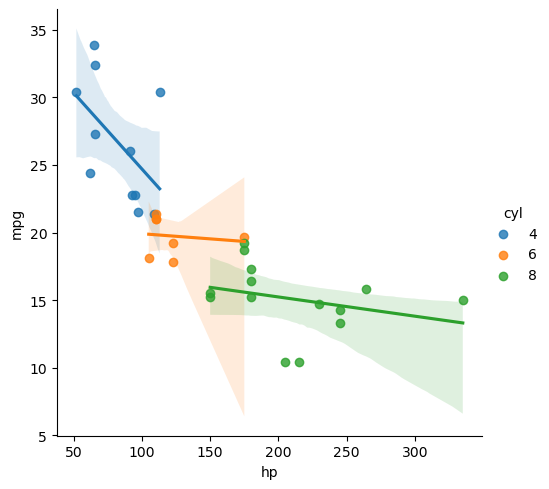

In [81]:
## Linear regression with interactions
## make interaction plot seaborn cyl, mpg, hp
sns.lmplot(x="hp", y="mpg", hue="cyl", data=mtcars);
mod12 = smf.ols('mpg ~ hp + C(cyl)', 
        data=mtcars).fit()
sm.stats.anova_lm(mod12, typ=2)

### Interactions in Models

We indicate interactions in models with the : (colon sign)
We can also use  *  as a shortcut to include the interaction and the lower terms:
x1*x2 -> expands to: x1 + x2 + x1:x2

In [83]:
## Test for an interaction here
mod13 = smf.ols('mpg ~ hp + C(cyl) + hp:C(cyl)', 
        data=mtcars).fit()
sm.stats.anova_lm(mod13, typ=2)

,sum_sq,df,F,PR(>F)
C(cyl),170.506588,2.0,9.295237,0.000901
hp,24.094872,1.0,2.627084,0.117121
hp:C(cyl),38.703057,2.0,2.109913,0.141533
Residual,238.464668,26.0,NaN,NaN


## Conclusions

After this tutorial, you have seen how easily Python, with Pandas, stastmodel, and Seaborn libraries can perform statistical tests (ttest, ANOVA), find correlations & regressions (with all the parameters you need to know to find the best fit) and can generate the plots you need to understand the underlying relationships in your data. 

The next module (Module 3) will lead you in hypothesis-free testing and machine learning.

### Clean up
Remember to shut down your Notebook compute instance when you are done for the day to avoid unnecessary charges. You can do this on the ml.azure.com toolbar.

##Solutions to Test your Knowledge questions below

In [ ]:
from scipy.stats import ttest_ind
## Solution for ttest of protein expression quiz
prot_exp_group = prot_exp.groupby("Group")
colors = {"Control": "blue", "Treated": "orange"}  # Define colors for groups
for name, group in prot_exp_group:
    plt.hist(group["Protein Expression (AU)"], bins=7, alpha=0.5, label=name, color=colors[name])

# Add labels and legend
plt.xlabel("Protein Expression (AU)")
plt.ylabel("Frequency")
plt.title("Histogram of Protein Expression by Treatment Type")
plt.legend()
plt.show()

result= prot_exp.groupby("Group")["Protein Expression (AU)"].agg(["mean", "std"])
print(result)
sns.boxplot(x="Group", y="Protein Expression (AU)", data=prot_exp);
sns.stripplot(x="Group", y="Protein Expression (AU)", data=prot_exp, color="red", alpha=0.6, jitter=True);
controlP=prot_exp[prot_exp["Group"]=="Control"]["Protein Expression (AU)"]
treatP=prot_exp[prot_exp["Group"]=="Treated"]["Protein Expression (AU)"]
# Perform independent two-sample t-test
t_stat, p_value = ttest_ind(controlP, treatP)

print(f"t-statistic: {t_stat}, p-value: {p_value}")

In [ ]:
#ANOVA for mut_rate.csv
import statsmodels.api as sm
from statsmodels.formula.api import ols
import os
mutrate=pd.read_csv("." +os.sep + "Datasets"+os.sep+ "mut_rate.csv")
# Create an OLS model
model = ols("Values  ~ Group", data=mutrate).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
#sns.boxplot(x="Group", y="Values", data=mutrate);
#sns.stripplot(x="Group", y="Values", data=mutrate, color="orange", alpha=0.6, jitter=True);